Import Libraries

In [1]:
import pandas as pd
import numpy as np
import re
import matplotlib.pyplot as plt

from tensorflow.keras.datasets import imdb

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report,
    ConfusionMatrixDisplay
)

Load IMDb Dataset

In [2]:
(x_train, y_train), (x_test, y_test) = imdb.load_data(
    num_words=10000
)

print("Training reviews:", len(x_train))
print("Testing reviews:", len(x_test))

17464789/17464789 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Training reviews: 25000
Testing reviews: 25000


Create Word Mapping

In [3]:
word_index = imdb.get_word_index()

reverse_word_index = {
    value: key
    for key, value in word_index.items()
}

print("Number of words in vocabulary:", len(reverse_word_index))

1641221/1641221 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Number of words in vocabulary: 88584


Decode Reviews

In [4]:
def decode_review(review):
    words = []

    for index in review:
        if index >= 3:
            word = reverse_word_index.get(index - 3, "")
            if word:
                words.append(word)

    return " ".join(words)

Convert Reviews into Text

In [5]:
train_text = [decode_review(review) for review in x_train]
test_text = [decode_review(review) for review in x_test]

print("Sample Review:")
print(train_text[0][:1000])

Sample Review:
this film was just brilliant casting location scenery story direction everyone's really suited the part they played and you could just imagine being there robert is an amazing actor and now the same being director father came from the same scottish island as myself so i loved the fact there was a real connection with this film the witty remarks throughout the film were great it was just brilliant so much that i bought the film as soon as it was released for and would recommend it to everyone to watch and the fly fishing was amazing really cried at the end it was so sad and you know what they say if you cry at a film it must have been good and this definitely was also to the two little boy's that played the of norman and paul they were just brilliant children are often left out of the list i think because the stars that play them all grown up are such a big profile for the whole film but these children are amazing and should be praised for what they have done don't you th

Create DataFrames

In [6]:
train_df = pd.DataFrame({
    "Review": train_text,
    "Sentiment": y_train
})

test_df = pd.DataFrame({
    "Review": test_text,
    "Sentiment": y_test
})

print("Training Data:")
display(train_df.head())

print("Testing Data:")
display(test_df.head())

Training Data:


,Review,Sentiment
0,this film was just brilliant casting location ...,1
1,big hair big boobs bad music and a giant safet...,0
2,this has to be one of the worst films of the 1...,0
3,the at storytelling the traditional sort many ...,1
4,worst mistake of my life br br i picked this m...,0


Testing Data:


,Review,Sentiment
0,please give this one a miss br br and the rest...,0
1,this film requires a lot of patience because i...,1
2,many animation buffs consider the great forgot...,1
3,i generally love this type of movie however th...,0
4,like some other people wrote i'm a die hard ma...,1


Check Class Distribution

In [7]:
print("Training Sentiment Distribution:")
print(train_df["Sentiment"].value_counts())

print("\nTesting Sentiment Distribution:")
print(test_df["Sentiment"].value_counts())

Training Sentiment Distribution:
Sentiment
1    12500
0    12500
Name: count, dtype: int64

Testing Sentiment Distribution:
Sentiment
0    12500
1    12500
Name: count, dtype: int64


Clean the Reviews

In [8]:
def clean_text(text):
    text = re.sub(r"<br\s*/?>", " ", text)
    text = re.sub(r"[^a-zA-Z\s]", " ", text)
    text = re.sub(r"\s+", " ", text)
    return text.lower().strip()

train_df["Cleaned_Review"] = train_df["Review"].apply(clean_text)
test_df["Cleaned_Review"] = test_df["Review"].apply(clean_text)

train_df[["Review", "Cleaned_Review"]].head()

,Review,Cleaned_Review
0,this film was just brilliant casting location ...,this film was just brilliant casting location ...
1,big hair big boobs bad music and a giant safet...,big hair big boobs bad music and a giant safet...
2,this has to be one of the worst films of the 1...,this has to be one of the worst films of the s...
3,the at storytelling the traditional sort many ...,the at storytelling the traditional sort many ...
4,worst mistake of my life br br i picked this m...,worst mistake of my life br br i picked this m...


Check Cleaned Review

In [9]:
print("Original Review:")
print(train_df["Review"].iloc[0][:500])

print("\nCleaned Review:")
print(train_df["Cleaned_Review"].iloc[0][:500])

Original Review:
this film was just brilliant casting location scenery story direction everyone's really suited the part they played and you could just imagine being there robert is an amazing actor and now the same being director father came from the same scottish island as myself so i loved the fact there was a real connection with this film the witty remarks throughout the film were great it was just brilliant so much that i bought the film as soon as it was released for and would recommend it to everyone to 

Cleaned Review:
this film was just brilliant casting location scenery story direction everyone s really suited the part they played and you could just imagine being there robert is an amazing actor and now the same being director father came from the same scottish island as myself so i loved the fact there was a real connection with this film the witty remarks throughout the film were great it was just brilliant so much that i bought the film as soon as it was released for and

Create TF-IDF Vectorizer

In [10]:
vectorizer = TfidfVectorizer(
    max_features=10000,
    stop_words="english",
    ngram_range=(1, 2)
)

X_train = vectorizer.fit_transform(train_df["Cleaned_Review"])
X_test = vectorizer.transform(test_df["Cleaned_Review"])

y_train = train_df["Sentiment"]
y_test = test_df["Sentiment"]

print("Training TF-IDF shape:", X_train.shape)
print("Testing TF-IDF shape:", X_test.shape)

Training TF-IDF shape: (25000, 10000)
Testing TF-IDF shape: (25000, 10000)


View TF-IDF Features

In [11]:
feature_names = vectorizer.get_feature_names_out()

print("Number of TF-IDF features:", len(feature_names))
print("\nFirst 20 features:")
print(feature_names[:20])

Number of TF-IDF features: 10000

First 20 features:
['abandon' 'abandoned' 'abc' 'abilities' 'ability' 'able' 'abortion'
 'abound' 'abraham' 'abrupt' 'abruptly' 'absence' 'absent' 'absolute'
 'absolutely' 'absolutely loved' 'absorbed' 'absorbing' 'absurd'
 'absurdity']


Train Logistic Regression

In [12]:
model = LogisticRegression(
    max_iter=1000
)

model.fit(X_train, y_train)

print("Logistic Regression model trained successfully.")

Logistic Regression model trained successfully.


Make Predictions

In [13]:
y_pred = model.predict(X_test)

print("First 20 Predictions:")
print(y_pred[:20])

First 20 Predictions:
[0 1 1 0 1 1 1 0 1 1 1 0 0 0 1 0 1 1 0 0]


Calculate Accuracy

In [14]:
accuracy = accuracy_score(y_test, y_pred)

print(f"Accuracy: {accuracy * 100:.2f}%")

Accuracy: 88.33%


Calculate Precision, Recall and F1 Score

In [15]:
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print(f"Precision: {precision * 100:.2f}%")
print(f"Recall:    {recall * 100:.2f}%")
print(f"F1 Score:  {f1 * 100:.2f}%")

Precision: 88.12%
Recall:    88.61%
F1 Score:  88.36%


Classification Report

In [16]:
print("Classification Report")


print(
    classification_report(
        y_test,
        y_pred,
        target_names=["Negative", "Positive"]
    )
)

Classification Report
              precision    recall  f1-score   support

    Negative       0.89      0.88      0.88     12500
    Positive       0.88      0.89      0.88     12500

    accuracy                           0.88     25000
   macro avg       0.88      0.88      0.88     25000
weighted avg       0.88      0.88      0.88     25000



Confusion Matrix

Confusion Matrix:
[[11007  1493]
 [ 1424 11076]]


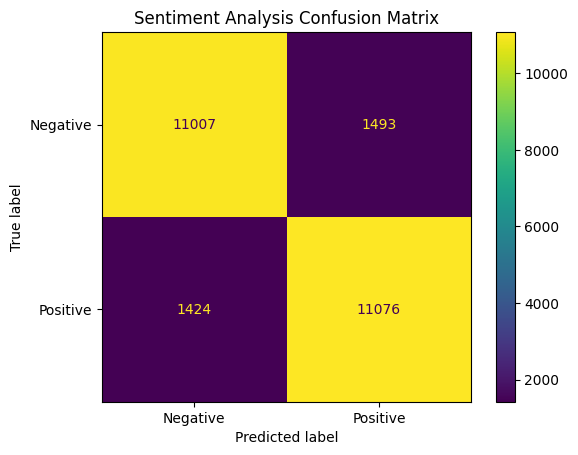

In [17]:
cm = confusion_matrix(y_test, y_pred)

print("Confusion Matrix:")
print(cm)

ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["Negative", "Positive"]
).plot()

plt.title("Sentiment Analysis Confusion Matrix")
plt.show()

Model Performance Summary

In [18]:
performance = pd.DataFrame({
    "Metric": [
        "Accuracy",
        "Precision",
        "Recall",
        "F1 Score"
    ],
    "Score (%)": [
        accuracy * 100,
        precision * 100,
        recall * 100,
        f1 * 100
    ]
})

performance

,Metric,Score (%)
0,Accuracy,88.332000
1,Precision,88.121569
2,Recall,88.608000
3,F1 Score,88.364115


Visualize Performance

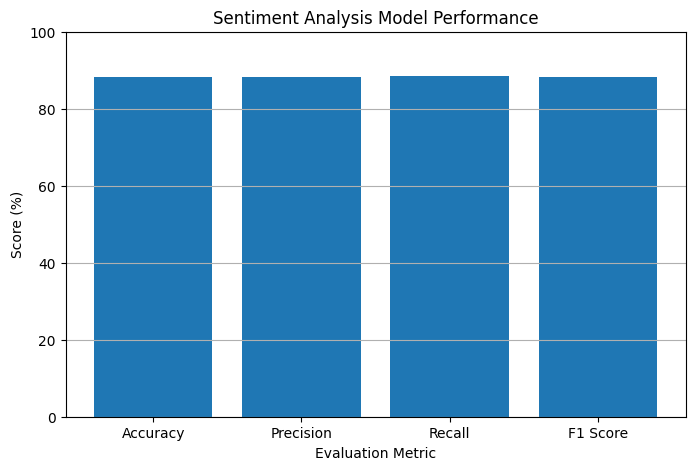

In [19]:
plt.figure(figsize=(8, 5))

plt.bar(
    performance["Metric"],
    performance["Score (%)"]
)

plt.xlabel("Evaluation Metric")
plt.ylabel("Score (%)")
plt.title("Sentiment Analysis Model Performance")
plt.ylim(0, 100)
plt.grid(axis="y")

plt.show()

Test Custom Reviews

In [20]:
custom_reviews = [
    "This movie was amazing and I really enjoyed it.",
    "The movie was boring, predictable and disappointing.",
    "An excellent film with great acting and a wonderful story.",
    "I did not like this movie at all."
]

custom_cleaned = [clean_text(review) for review in custom_reviews]

custom_features = vectorizer.transform(custom_cleaned)

custom_predictions = model.predict(custom_features)

for review, prediction in zip(custom_reviews, custom_predictions):
    sentiment = "Positive" if prediction == 1 else "Negative"

    print("Review:", review)
    print("Prediction:", sentiment)
    print()

Review: This movie was amazing and I really enjoyed it.
Prediction: Positive

Review: The movie was boring, predictable and disappointing.
Prediction: Negative

Review: An excellent film with great acting and a wonderful story.
Prediction: Positive

Review: I did not like this movie at all.
Prediction: Negative



Final Project Summary

In [22]:
print("DAY 14 — SENTIMENT ANALYSIS PROJECT")

print("Dataset: IMDb Movie Reviews")
print("Model: Logistic Regression")
print("Feature Extraction: TF-IDF")

print(f"\nAccuracy : {accuracy * 100:.2f}%")
print(f"Precision: {precision * 100:.2f}%")
print(f"Recall   : {recall * 100:.2f}%")
print(f"F1 Score : {f1 * 100:.2f}%")

print("\nProject Workflow:")
print("1. Loaded IMDb reviews")
print("2. Cleaned the text")
print("3. Converted text into TF-IDF features")
print("4. Trained Logistic Regression")
print("5. Evaluated the model")
print("6. Tested custom reviews")

DAY 14 — SENTIMENT ANALYSIS PROJECT
Dataset: IMDb Movie Reviews
Model: Logistic Regression
Feature Extraction: TF-IDF

Accuracy : 88.33%
Precision: 88.12%
Recall   : 88.61%
F1 Score : 88.36%

Project Workflow:
1. Loaded IMDb reviews
2. Cleaned the text
3. Converted text into TF-IDF features
4. Trained Logistic Regression
5. Evaluated the model
6. Tested custom reviews
